In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}
table.dataframe{font-size:22px;}
table td, th{font-size:16px;}
table{ margin-left:0 !important;   /* 왼쪽 여백 0 */}
</style>
"""))


**<font size="6" color="red">ch1. 허깅페이스 모델 사용</font>**
- Inference API 이용 : 모델의 결과를 server에서
- pipeline() 이용 : 모델을 다운로드 받아 모델의 결과를 local에서 

- 허깅페이스 transformer에서 지원하는 task
<div align="left">
| task값 | 설명 |
| :--- | :--- |
| text-classification (별칭 sentiment-analysis) |	감정 분석, 뉴스 분류, 리뷰 분류 등 문장 분류 |
| zero-shot-classification | 레이블에 대한 별도 학습 없이 후보 레이블 중에서 분류 |
| text-generation	| GPT 계열 모델을 이용한 텍스트 생성 |
| fill-mask |	문장 안의 빈칸(마스크)에 들어갈 단어 예측 |
| ner (token-classification의 별칭) |	개체명 인식(사람, 조직, 장소 등 라벨링) |
| question-answering |	주어진 지문(context)을 근거로 질문에 답변 |
| summarization	| 긴 문서를 짧게 요약 |
| translation |	서로 다른 언어 간 번역 |
| image-to-text | 이미지 내용을 설명하는 문장 생성 |
| image-classification | 이미지가 어떤 대상인지 분류 |
</div>

- 처음 모델 사용시 "c:/Users/내컴퓨터이름/.cache/huggingface"에 다운로드되느라 시간이 걸림

In [2]:
import warnings
import os
import logging
 
# 경고 메시지 제거
warnings.filterwarnings('ignore')
 
# transformers 라이브러리의 로깅 레벨을 ERROR로 조정 (경고 숨김)
logging.getLogger("transformers").setLevel(logging.ERROR)
 
# Hugging Face 캐시 관련 symlink 경고 제거
# os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. 텍스트 기반 감정분석(긍정/부정)
- 토큰화 -> 워드임베딩 -> 모델 -> predict : pipeline()함수는 이 단계를 내부적으로 해줌

In [3]:
from transformers import pipeline
classifier = pipeline(task="text-classification", model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
classifier("I've been waiting for a Hugging face course my whole life.")

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9982948899269104}]

In [4]:
# 특정 모델의 파라미터와 용량
from transformers import AutoModel
model = AutoModel.from_pretrained("distilbert/distilbert-base-uncased-finetuned-sst-2-english")

# 전체 파라미터 수
total_params = sum(p.numel() for p in model.parameters() )
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 수: {total_params/1024/1024:.3f}MB")

전체 파라미터 수: 66,362,880
전체 파라미터 수: 63.289MB


In [5]:
from transformers import pipeline
classifier = pipeline(task="sentiment-analysis",
                     model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")

# 감정분석할 내용이 많으면 list'
classifier([
    "I've been waiting for a Hugging face course my whole life.",
    "I hate this so much!"
])

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9982948899269104},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

In [6]:
classifier("이 영화 정말 최고였어요. 감동적이고 연기도 대단해요!")

[{'label': 'POSITIVE', 'score': 0.975276529788971}]

In [7]:
classifier(["I like you", "I hate you", "힘들어요"])

[{'label': 'POSITIVE', 'score': 0.9998695850372314},
 {'label': 'NEGATIVE', 'score': 0.9991129040718079},
 {'label': 'POSITIVE', 'score': 0.8669533729553223}]

In [8]:
classifier = pipeline(task="sentiment-analysis",
                     model="daekeun-ml/koelectra-small-v3-nsmc")
texts = ['어찌 범부가 황새의 생각을 알겠습니까', '내가 울어도 파도는 밀려온다', '권선징악', '사랑시 고백구 행복동', '너가 좋아']
classifier(texts)

Device set to use cpu


[{'label': '1', 'score': 0.9794293642044067},
 {'label': '1', 'score': 0.8904697299003601},
 {'label': '1', 'score': 0.9947885274887085},
 {'label': '1', 'score': 0.9992324113845825},
 {'label': '1', 'score': 0.5141964554786682}]

In [9]:
for text, result in zip(texts, classifier(texts)):
    label = "긍정" if result['label']=='1' else "부정"
    print(f"'{text}' -> {label} {result['score']:.2%}")

'어찌 범부가 황새의 생각을 알겠습니까' -> 긍정 97.94%
'내가 울어도 파도는 밀려온다' -> 긍정 89.05%
'권선징악' -> 긍정 99.48%
'사랑시 고백구 행복동' -> 긍정 99.92%
'너가 좋아' -> 긍정 51.42%


# 2. 제로샷(Zero-shot-분류)
- 비지도학습
```
제로샷 분류는 기계학습 및 자연어 처리에서 개별 작업에 대한 별도의 학습(파인튜닝) 없이도 분류 작업을 수행할 수 있는 방식이다. 
분류하고자 하는 후보 레이블(candidate_labels)만 지정해 주면, 
모델이 사전에 학습한 언어 지식을 바탕으로 입력 문장이 어떤 레이블에 가장 가까운지 확률로 계산해 준다.
```

In [10]:
classifier = pipeline(
    task='zero-shot-classification',
    model='facebook/bart-large-mnli' )

classifier(
    "I have a problem with iphone that needs to be resolved asap!!",
    candidate_labels=['phone', 'urgent', 'tablet', 'computer'] )

Device set to use cpu


{'sequence': 'I have a problem with iphone that needs to be resolved asap!!',
 'labels': ['phone', 'urgent', 'computer', 'tablet'],
 'scores': [0.6188073754310608,
  0.37655454874038696,
  0.003668452613055706,
  0.000969655578956008]}

In [11]:
classifier("This is a course about the Tranformers library.",
          candidate_labels=["education", "business", "phone"])

{'sequence': 'This is a course about the Tranformers library.',
 'labels': ['education', 'business', 'phone'],
 'scores': [0.8320797681808472, 0.09927219897508621, 0.06864806264638901]}

# 3. text 생성
- gpt2 : 파라미터개수 124,439,808개
- 모델 용량 : 124,439,808*4 → 118.675MB
- finetuning시 추가 메모리 : 학습시 활성화함수, 옵티마이저, 미분, 데이터 ... 등으로 대략 4배 메모리 필요

In [12]:
# 특정 모델의 파라미터와 용량
from transformers import AutoModel
model = AutoModel.from_pretrained("gpt2")

# 전체 파라미터 수
total_params = sum(p.numel() for p in model.parameters() )
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 수: {total_params/1024/1024:.3f}MB")

전체 파라미터 수: 124,439,808
전체 파라미터 수: 118.675MB


In [13]:
generator = pipeline(
    task="text-generation",
    model="gpt2" )
generator("In this course. We will teach you how to ",
         pad_token_id=generator.tokenizer.eos_token_id)

Device set to use cpu


[{'generated_text': "In this course. We will teach you how to _____________, as well as the basics of the _____________ commands, so that you can become proficient in _____________ commands without having to learn a new language. If you're learning commands from a different language, or you might just want to learn the _____________ command from an _____________ command, this course will help you learn the _____________ commands the way you would learn _____________ commands from a native speaker. If you're not familiar with a native speaker, or you're looking for an _____________ command, this course will provide you with a good understanding of the _____________ commands that are used by _____________ commands.\n\nThis course is meant to be taken in order to be able to learn the _____________ commands in languages other than the _____________ languages. In other words, you won't learn _____________ commands without learning _____________ commands from other _____________ languages. T

In [14]:
result = generator("In this course. We will teach you how to ",
              pad_token_id=generator.tokenizer.eos_token_id)
print(result[0]['generated_text'])

In this course. We will teach you how to  create a web app that will let you create a lot of websites in a short, easy to read, and easy to use way. If you are a technical person, you know that a lot of web developers just don't understand how to write web apps. So we'll learn to write your own web app. We will start by explaining the fundamentals of how you can create a web app. We will show you how to create your own app, how to configure your app, and how to create a database. Then we will show you how to write your own database and how to create a web app. Finally, we will show you how to create a database and how to create a database using PHP. Let's start.
Now, we will create a database and a web app. Let's see how to create it. We will start with a quick example. We'll start with a quick example. We will start with a quick example. We will create a quick app with simple settings. When you open the app, we will see that all the settings are set to default. When you open the app, 

In [15]:
generator = pipeline("text-generation", "skt/kogpt2-base-v2", device=-1) # device=-1 GPU를 사용하려면 0으로 설정
prompt = "이 과정은 다음과 같은 것을 알려드려요."
result = generator(
    prompt,
    pad_token_id=generator.tokenizer.eos_token_id,
    max_new_tokens=20,
    do_sample=True,  # 샘플링 사용
    top_k=50,              # 토큰 후보 폭을 다양하게 확보
    temperature=0.8, # 0.2는 너무 보수적, 0.9정도는 유연한 대답
    top_p = 0.9,         # 상위 90% 누적 확률 토큰만
    repetition_penalty=1.2 # 반복적인 단어는 패널티를 
)
print(result[0]['generated_text'] )

Device set to use cpu


이 과정은 다음과 같은 것을 알려드려요." 그는 다시 한번 이야기했다.
"왜냐하면 나는 이제부터 단지 '두 번째 과정'만을


# 4. 마스크 채우기

In [16]:
unmasker = pipeline(
    task="fill-mask",
    model="distilbert/distilroberta-base") # 마스크 채우기
unmasker("I'm goint to hospital and meet a <mask>", top_k=2)

Some weights of the model checkpoint at distilbert/distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.16158527135849,
  'token': 3299,
  'token_str': ' doctor',
  'sequence': "I'm goint to hospital and meet a doctor"},
 {'score': 0.09415878355503082,
  'token': 1441,
  'token_str': ' friend',
  'sequence': "I'm goint to hospital and meet a friend"}]

In [17]:
unmasker("병원에 가서 <mask>를 만날거에요", top_k=2) # top_k 기본값은 5

[{'score': 0.5491088628768921,
  'token': 1437,
  'token_str': ' ',
  'sequence': '병원에 가서 를 만날거에요'},
 {'score': 0.07508302479982376,
  'token': 12,
  'token_str': '-',
  'sequence': '병원에 가서-를 만날거에요'}]

In [18]:
# unmasker = pipeline("fill-mask", "google-bert/bert-base-uncased")
# unmasker("Hello, I'm a [MASK] model.")

### inference API 이용
- 모델의 결과를 server에게

In [19]:
import os
from dotenv import load_dotenv
load_dotenv()
print(os.getenv('HF_TOKEN')[:2] )

hf


In [20]:
from huggingface_hub import InferenceClient
client = InferenceClient(
    provider='hf-inference',
    #api_key=os.getenv('HF_TOKEN')
)
result = client.fill_mask("Hello, I'm a [MASK] model.",
                             model="google-bert/bert-base-uncased",
                             #top_k=2
                         )
result

[FillMaskOutputElement(score=0.1441427320241928, sequence="hello, i ' m a role model.", token=2535, token_str='role', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.14175812900066376, sequence="hello, i ' m a fashion model.", token=4827, token_str='fashion', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.06221463158726692, sequence="hello, i ' m a new model.", token=2047, token_str='new', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.04102848470211029, sequence="hello, i ' m a super model.", token=3565, token_str='super', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.02591117098927498, sequence="hello, i ' m a business model.", token=2449, token_str='business', fill_mask_output_token_str=None)]

In [21]:
[r.sequence for r in result]

["hello, i ' m a role model.",
 "hello, i ' m a fashion model.",
 "hello, i ' m a new model.",
 "hello, i ' m a super model.",
 "hello, i ' m a business model."]

In [22]:
# 다국어 지원되는 mask모델
from transformers import pipeline
unmasker = pipeline("fill-mask", "google-bert/bert-base-multilingual-cased")
unmasker("안녕하세요. 나는 [MASK] 모델입니다", top_k=3)

Some weights of the model checkpoint at google-bert/bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.19656701385974884,
  'token': 108399,
  'token_str': '가수',
  'sequence': '안녕하세요. 나는 가수 모델입니다'},
 {'score': 0.13671618700027466,
  'token': 62592,
  'token_str': '여자',
  'sequence': '안녕하세요. 나는 여자 모델입니다'},
 {'score': 0.04897935315966606,
  'token': 102574,
  'token_str': '프로',
  'sequence': '안녕하세요. 나는 프로 모델입니다'}]

In [23]:
[r['sequence'] for r in result]

["hello, i ' m a role model.",
 "hello, i ' m a fashion model.",
 "hello, i ' m a new model.",
 "hello, i ' m a super model.",
 "hello, i ' m a business model."]

# 5. 개체명 인식(NER; Named Entity Recognition)

In [24]:
ner = pipeline(
    "ner",
    "dbmdz/bert-large-cased-finetuned-conll03-english",
      grouped_entities=True ) # 객체들을 그룹으로 묶을지 말지
ner("My name is Sylvain and I work at Hugging Face in Brooklyn.")

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'entity_group': 'PER',
  'score': 0.9981694,
  'word': 'Sylvain',
  'start': 11,
  'end': 18},
 {'entity_group': 'ORG',
  'score': 0.9796019,
  'word': 'Hugging Face',
  'start': 33,
  'end': 45},
 {'entity_group': 'LOC',
  'score': 0.9932106,
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

# 6. 질의응답
- context에 대한 질의 응답

In [25]:
question_answer = pipeline("question-answering")
# question-answering 타스크의 기본 모델 : distilbert/distilbert-base-cased-distilled-squad
question_answer(
    question="Where do I work?",
    context="My name is Sylvain and I work at Hugging Face in Brooklyn."
) # context 지문을 이용해서 답을 하는 것

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


{'score': 0.6385911703109741, 'start': 33, 'end': 45, 'answer': 'Hugging Face'}

In [26]:
context = "My name is Sylvain and I work at Hugging Face in Brooklyn."
context[33:45]

'Hugging Face'

## 7. 문서요약
- torch 버전 2.6보다 낮으면 문서요약 안 될 수 있음

In [27]:
summarizer = pipeline("summarization", 
                        "facebook/bart-large-cnn")
summarizer('''
The rapid expansion of artificial intelligence is creating new risks
for global financial stability, according to the head of the Bank for
International Settlements.

The world's five largest technology companies are expected to invest
more than $1 trillion in AI between 2025 and 2026. Global AI investment
could reach as much as $4 trillion by 2030.

AI can significantly improve productivity, particularly in areas such
as coding, consulting and professional writing. However, the rapid
growth of AI investment is also creating concerns about high valuations,
market concentration and opaque financing.

Much of the recent AI investment is being financed through debt and
private credit rather than corporate earnings. This could create
financial vulnerabilities if expected returns from AI fail to
materialize.

AI is also changing global trade. Countries such as South Korea,
Singapore, Malaysia and Taiwan are benefiting from increased demand
for AI chips and related equipment.

The BIS warned that AI could also replace some routine cognitive tasks,
potentially affecting jobs in customer service, programming and
administrative work. The long-term economic impact of AI will depend
on investment in skills, infrastructure and appropriate policy.''',
          max_length=130, 
          min_length=30, 
          do_sample=True)

Device set to use cpu


[{'summary_text': "The world's five largest technology companies are expected to invest more than $1 trillion in AI between 2025 and 2026. Global AI investment could reach as much as $4 trillion by 2030. The long-term economic impact of AI will depend on investment in skills, infrastructure and appropriate policy."}]

# 8. 번역 

In [28]:
# pip install sacremoses
translator = pipeline('translation', 'Helsinki-NLP/opus-mt-fr-en') # 프랑스어 → 영어

Device set to use cpu


In [29]:
translator('Ce cours est produit par Hugging Face.')

[{'translation_text': 'This course is produced by Hugging Face.'}]

In [30]:
# 한 → 영
ko2en = pipeline("translation", model="Helsinki-NLP/opus-mt-ko-en")
# 영 → 한(불량 많음)
en2ko = pipeline("translation", model="Helsinki-NLP/opus-mt-tc-big-ko-en")
# 테스트 문장
ko_sentence = "이 문장을 영어로 번역해주세요."
en_sentence = "I enjoy learning about AI"
# 번역
print('한→영 :', ko2en(ko_sentence)[0]['translation_text'])
print('영→한 :', en2ko(en_sentence)[0]['translation_text'])

Device set to use cpu
Device set to use cpu


한→영 : Translate this sentence into English.
영→한 : Tell the door to my program.


In [31]:
result = ko2en([
    '안녕, 오늘 하루는 어땠나요',
    '오늘 날씨만큼 흐렸나요',
    '화창하진 않았대도 자그만 행복이 깃들었길 바래요.'
])
[r['translation_text'] for r in result]

['Hi. How was your day?',
 "It's been as dark as the weather today.",
 "I hope you're happy."]

## 9. 이미지를 설명하는 텍스트(Image-to-Text)

<class 'numpy.ndarray'> (150, 200)


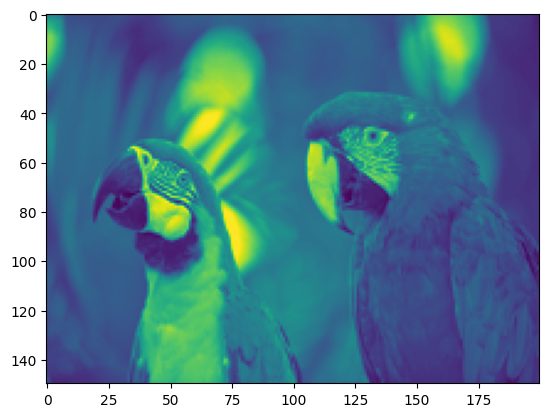

In [33]:
import requests
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO

url = 'https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png'

response = requests.get(url, timeout=10).raw

image = Image.open(BytesIO(response.content))
image = image.resize((200, 150))

image_npy = np.array(image)

print(type(image_npy), image_npy.shape)

plt.imshow(image_npy)
plt.show()

In [34]:
from transformers import pipeline
imagetotext = pipeline("image-to-text",
                      "ydshieh/vit-gpt2-coco-en")
imagetotext(url, max_new_tokens=30) # 30토큰 내로 설명

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


[{'generated_text': 'two birds are standing next to each other '}]

In [35]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
response = requests.get(url, stream=True).raw
image = Image.open(response)
imagetotext(url, max_new_tokens=50)

[{'generated_text': 'a cat laying on a blanket next to a cat laying on a bed '}]

In [38]:
filename = 'images/fb.jpg'
# Image.open(filename)
imagetotext(filename, max_new_tokens=50)

ValueError: Incorrect image source. Must be a valid URL starting with `http://` or `https://`, a valid path to an image file, or a base64 encoded string. Got images/fb.jpg. Failed with cannot identify image file <_io.BytesIO object at 0x00000227C707C310>

# 10. 이미지분류

In [39]:
image = Image.open('images/cat.jpg')
image.resize((200,200))

FileNotFoundError: [Errno 2] No such file or directory: 'images/cat.jpg'

In [40]:
imgclassifier = pipeline("image-classification",
                        "google/vit-base-patch16-224")
imgclassifier(image)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


[{'label': 'Egyptian cat', 'score': 0.9374417066574097},
 {'label': 'tabby, tabby cat', 'score': 0.038442544639110565},
 {'label': 'tiger cat', 'score': 0.01441141963005066},
 {'label': 'lynx, catamount', 'score': 0.0032743136398494244},
 {'label': 'Siamese cat, Siamese', 'score': 0.000679591903463006}]